# Stylized Facts 分析ノートブック

`output.csv`（S&P 500 日次リターン `sp500` + 米 10 年国債利回り日次変化 `DGS10`，
1966-01-03 〜 2026-05-14, 14,884 営業日）を使ってすべての分析を自動計算・可視化する．

> **実データの参照期間について**
> セクション 1〜9 では実データ（`output.csv`）の**全期間（1966〜2026年・約60年・14,884日）**を参照として使用する．
> セクション 10 のみ 2023〜2025 年の直近期間を比較対象として使用する．

---

## 目次
1. [セットアップ & データ読み込み](#1-セットアップ--データ読み込み)
2. [ファットテール](#2-ファットテール)
3. [リターンの非対称性](#3-リターンの非対称性)
4. [ボラティリティクラスタリング & リターン自己相関](#4-ボラティリティクラスタリング--リターン自己相関)
5. [レバレッジ効果](#5-レバレッジ効果)
6. [相関の時変性](#6-相関の時変性)
7. [相関の非対称性](#7-相関の非対称性)
8. [ボラティリティと相関の連動性](#8-ボラティリティと相関の連動性)
9. [リード・ラグ現象](#9-リードラグ現象)
10. [Diffusion Model 生成結果の検証例](#10-diffusion-model-生成結果の検証例)

## 1. セットアップ & データ読み込み

In [288]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['font.family'] = ['Noto Sans CJK JP', 'sans-serif']

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


In [289]:
# ============================================================
# 実データ参照の表示切り替え
SHOW_REAL = True
# ============================================================

# ============================================================
# 分析対象データの切り替え
# ============================================================
#
# ── [A] 実データ（デフォルト） ──────────────────────────────
# df = pd.read_csv("output.csv", parse_dates=["Date"])
# _using_real = True
#
# ── [B] 生成データ ──────────────────────────────────────────
#
# _gen = pd.read_csv("diffusion/generated_paths.csv", parse_dates=["Date"])
# _using_real = False
#
# ── [C] 生成データ ──────────────────────────────────────────

_gen = pd.read_csv("sign_ablation/cond_random/generated_paths.csv", parse_dates=["Date"])
_using_real = False

# ============================================================

if _using_real:
    df = pd.read_csv("output.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    _all_paths = [df]          # 実データは1本だけ
else:
    # 全パスを個別 DataFrame に分解（統計量の per-path 集計用）
    _pids = sorted(_gen["path_id"].unique())
    _all_paths = [
        _gen[_gen["path_id"] == pid].drop(columns="path_id")
            .sort_values("Date").reset_index(drop=True)
        for pid in _pids
    ]
    df = _all_paths[0]   # 可視化用に 1 パスを保持（path_id=0）

sp     = df["sp500"].dropna()
dg     = df["DGS10"].dropna()
sp_abs = df["sp500_abs"]
dg_abs = df["DGS10_abs"]
dates  = df["Date"]

# 実データ参照（SHOW_REAL 用）
df_real_ref = (pd.read_csv("output.csv", parse_dates=["Date"])
               .sort_values("Date").reset_index(drop=True))
sp_ref = df_real_ref["sp500"].dropna().reset_index(drop=True)
dg_ref = df_real_ref["DGS10"].dropna().reset_index(drop=True)

_show_real = SHOW_REAL and not _using_real

n_paths_str = f"{len(_all_paths)} パス" if not _using_real else "実データ"
print(f"期間  : {df['Date'].min().date()} 〜 {df['Date'].max().date()}")
print(f"行数  : {len(df):,} 営業日 / {n_paths_str}")
print(f"sp500 : mean={sp.mean()*100:.4f}%/日  std={sp.std()*100:.3f}%/日")
print(f"DGS10 : mean={dg.mean():.4f} %pt/日  std={dg.std():.4f} %pt/日")
print(f"SHOW_REAL={SHOW_REAL}, _show_real={_show_real}")
df[["sp500","DGS10"]].describe().round(4)

期間  : 2026-05-15 〜 2027-05-03
行数  : 252 営業日 / 20 パス
sp500 : mean=0.0642%/日  std=0.650%/日
DGS10 : mean=0.0016 %pt/日  std=0.0706 %pt/日
SHOW_REAL=True, _show_real=True


,sp500,DGS10
count,252.0000,252.0000
mean,0.0006,0.0016
std,0.0065,0.0706
min,-0.0133,-0.2647
25%,-0.0041,-0.0384
50%,0.0002,-0.0041
75%,0.0048,0.0344
max,0.0256,0.2733


## 2. ファットテール

リターン分布の裾が正規分布より重いことを視覚的に確認する．

* **ヒストグラム**: 中心 98% に当てはめた正規曲線と比較
* **Q-Q プロット**: 正規分布との乖離 — 両端が直線から外れるほどファットテール


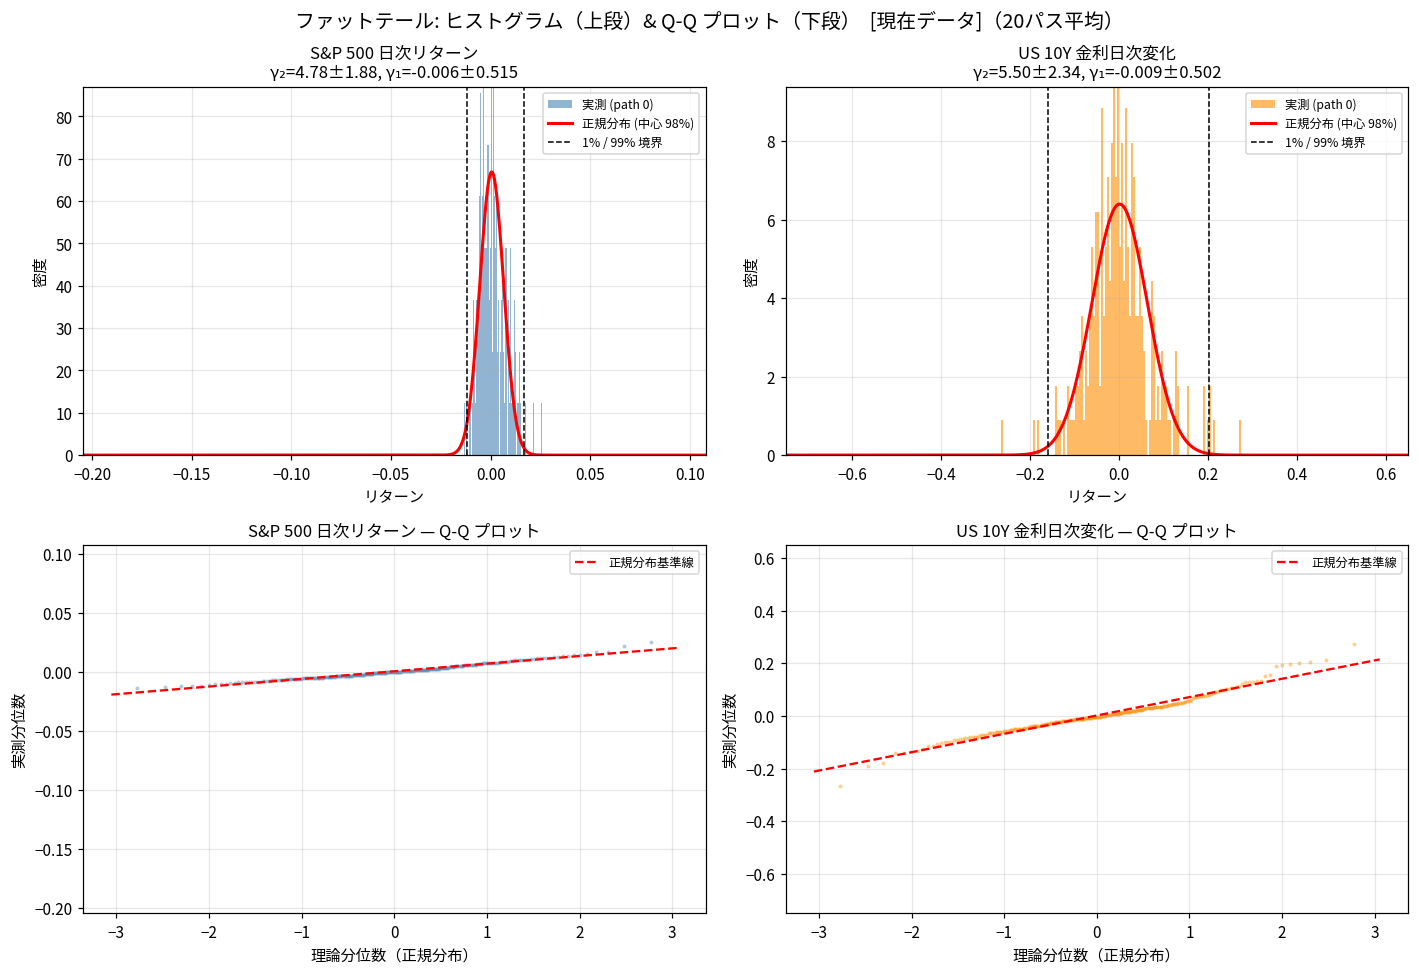

[現在データ]（20パス平均）
               尖度 γ₂ mean±std     歪度 γ₁ mean±std     JB p値 mean
-----------------------------------------------------------------
  sp500              4.78±1.88        -0.006±0.515        1.13e-01
  DGS10              5.50±2.34        -0.009±0.502        1.12e-02



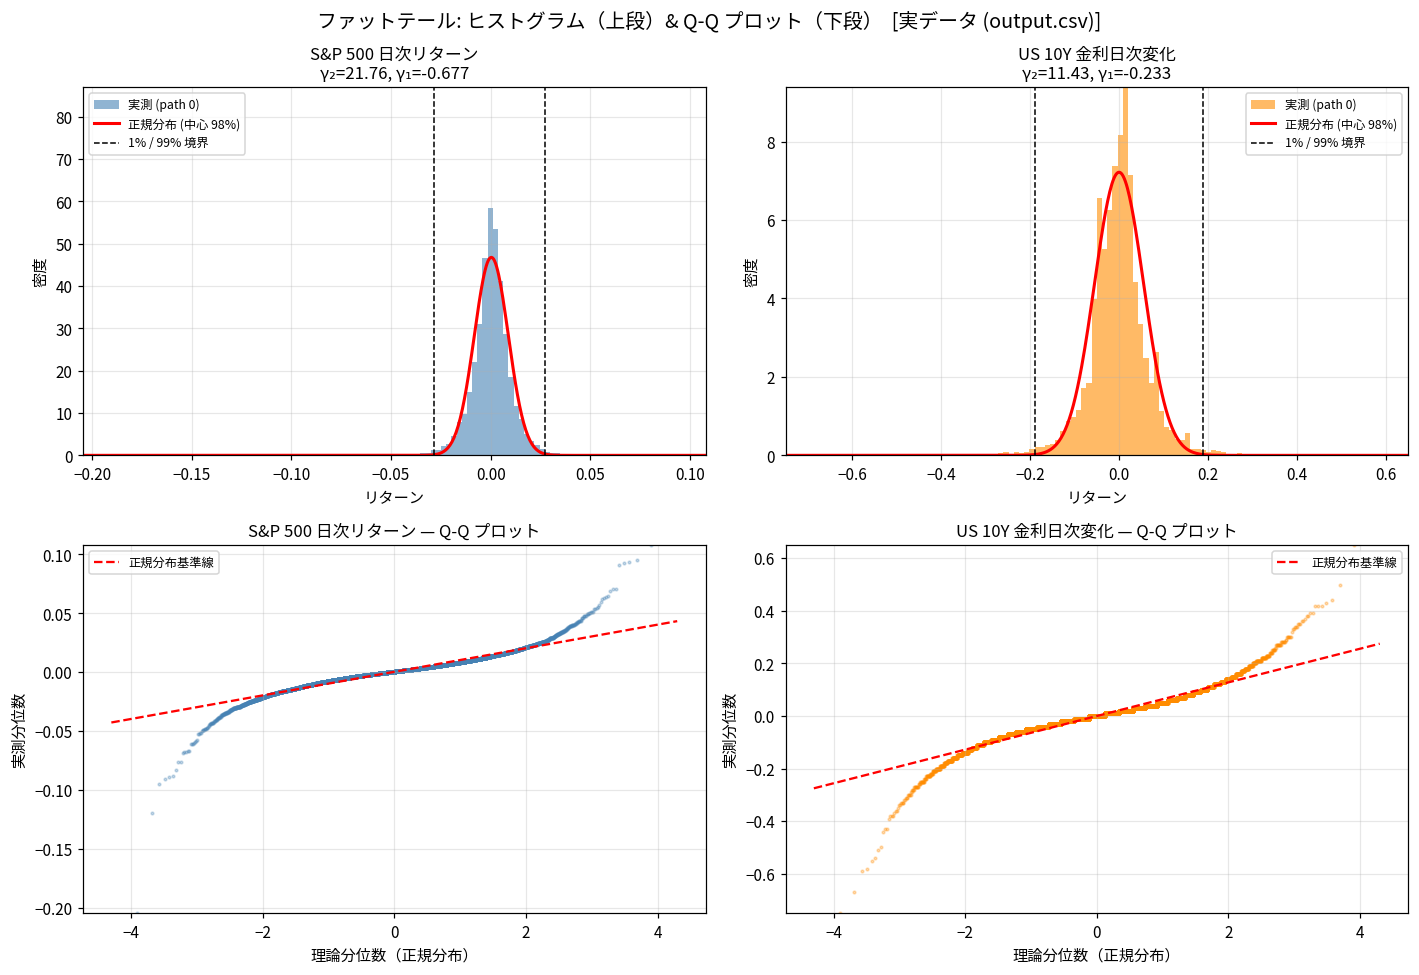

[実データ (output.csv)]
               尖度 γ₂ mean±std     歪度 γ₁ mean±std     JB p値 mean
-----------------------------------------------------------------
  sp500             21.76±0.00        -0.677±0.000        0.00e+00
  DGS10             11.43±0.00        -0.233±0.000        0.00e+00



In [290]:
_datasets = [(df, "現在データ", _all_paths)]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)", [df_real_ref]))

_col_keys   = ["sp500", "DGS10"]
_col_labels = ["S&P 500 日次リターン", "US 10Y 金利日次変化"]
_col_colors = ["steelblue", "darkorange"]

# スケール統一（可視化用 path_id=0 ベース）
_xlim = {}; _qlim = {}; _dlim = {}
for col in _col_keys:
    all_r = pd.concat([_data[col].dropna() for _data, _, _ in _datasets])
    _xlim[col] = (float(all_r.min()), float(all_r.max()))
    _qlim[col] = (float(all_r.min()), float(all_r.max()))
    max_dens = 0.0
    for _data, _, _ in _datasets:
        r = _data[col].dropna()
        lo, hi = np.percentile(r, 1), np.percentile(r, 99)
        r_c = r[(r >= lo) & (r <= hi)]
        sig = r_c.std()
        if sig > 0:
            max_dens = max(max_dens, 1.0 / (sig * np.sqrt(2 * np.pi)))
    _dlim[col] = max_dens * 1.3

for _data, _dlabel, _paths in _datasets:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for col_idx, (col, color, label) in enumerate(
            zip(_col_keys, _col_colors, _col_labels)):
        # 可視化は path_id=0（_data）を使用
        r = _data[col].dropna()
        lo, hi = np.percentile(r, 1), np.percentile(r, 99)
        r_c = r[(r >= lo) & (r <= hi)]
        mu, sigma = r_c.mean(), r_c.std()

        # タイトルの統計量は全パス平均
        kurts = [stats.kurtosis(p[col].dropna(), fisher=True) + 3 for p in _paths]
        skews = [float(p[col].dropna().skew()) for p in _paths]
        kurt_str = f"{np.mean(kurts):.2f}±{np.std(kurts):.2f}" if len(_paths)>1 else f"{kurts[0]:.2f}"
        skew_str = f"{np.mean(skews):.3f}±{np.std(skews):.3f}" if len(_paths)>1 else f"{skews[0]:.3f}"

        ax_h = axes[0, col_idx]
        ax_h.hist(r, bins=120, density=True, color=color, alpha=0.6, label="実測 (path 0)")
        x = np.linspace(_xlim[col][0], _xlim[col][1], 600)
        ax_h.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label="正規分布 (中心 98%)")
        ax_h.axvline(lo, color="k", ls="--", lw=1, label="1% / 99% 境界")
        ax_h.axvline(hi, color="k", ls="--", lw=1)
        ax_h.set_xlim(_xlim[col]); ax_h.set_ylim(0, _dlim[col])
        ax_h.set_title(f"{label}\nγ₂={kurt_str}, γ₁={skew_str}")
        ax_h.set_xlabel("リターン"); ax_h.set_ylabel("密度")
        ax_h.legend(fontsize=8)

        ax_q = axes[1, col_idx]
        (osm, osr), (slope, intercept, _) = stats.probplot(r, dist="norm")
        ax_q.scatter(osm, osr, s=3, alpha=0.3, color=color)
        xlim_q = ax_q.get_xlim()
        ax_q.plot(xlim_q, [slope * v + intercept for v in xlim_q], "r--", lw=1.5,
                  label="正規分布基準線")
        ax_q.set_ylim(_qlim[col])
        ax_q.set_title(f"{label} — Q-Q プロット")
        ax_q.set_xlabel("理論分位数（正規分布）"); ax_q.set_ylabel("実測分位数")
        ax_q.legend(fontsize=8)

    suffix = f"（{len(_paths)}パス平均）" if len(_paths)>1 else ""
    fig.suptitle(f"ファットテール: ヒストグラム（上段）& Q-Q プロット（下段）  [{_dlabel}]{suffix}",
                 fontsize=13)
    plt.tight_layout(); plt.show()

    # 統計サマリー（全パス平均±std）
    print(f"[{_dlabel}]{suffix}")
    print(f"  {'':8} {'尖度 γ₂ mean±std':>18} {'歪度 γ₁ mean±std':>18} {'JB p値 mean':>14}")
    print("-" * 65)
    for col, lbl in zip(_col_keys, ["sp500","DGS10"]):
        kurts  = [stats.kurtosis(p[col].dropna(), fisher=True)+3 for p in _paths]
        skews  = [float(p[col].dropna().skew()) for p in _paths]
        jb_ps  = [stats.jarque_bera(p[col].dropna())[1] for p in _paths]
        k_str  = f"{np.mean(kurts):6.2f}±{np.std(kurts):.2f}"
        s_str  = f"{np.mean(skews):6.3f}±{np.std(skews):.3f}"
        print(f"  {lbl:8}  {k_str:>18}  {s_str:>18}  {np.mean(jb_ps):>14.2e}")
    print()

## 3. リターンの非対称性

同じ分位数で `|負のリターン|`（青）と `正のリターン`（赤）を比較．
青点が赤点を上回る → 下落幅の方が大きい（左歪み）．


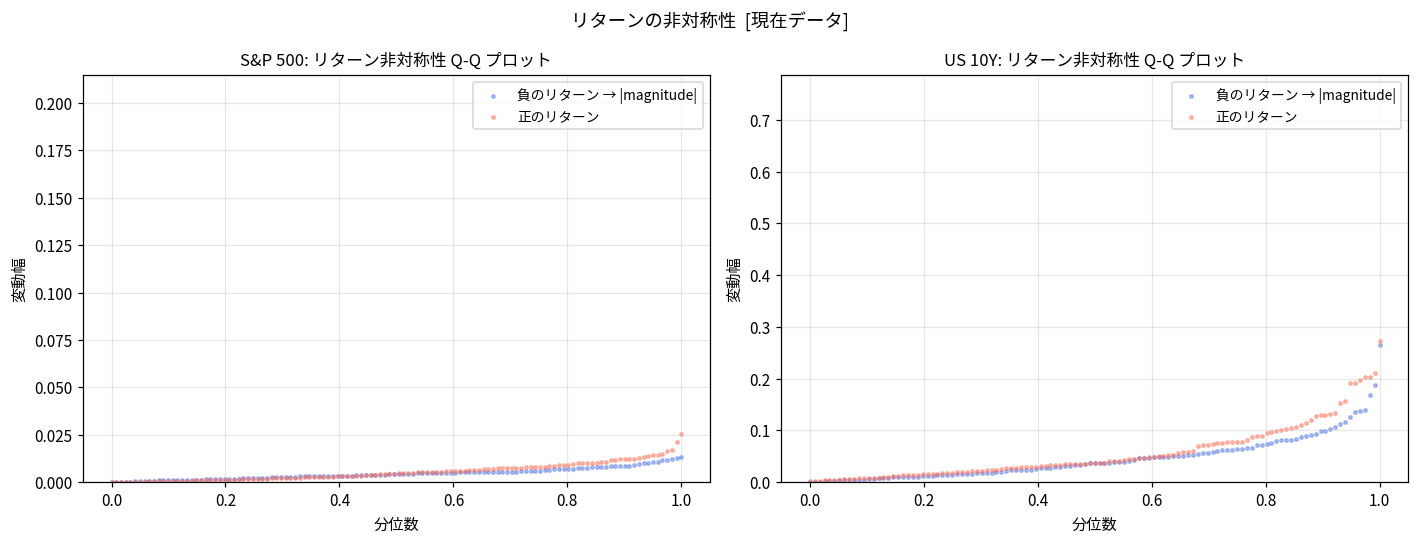

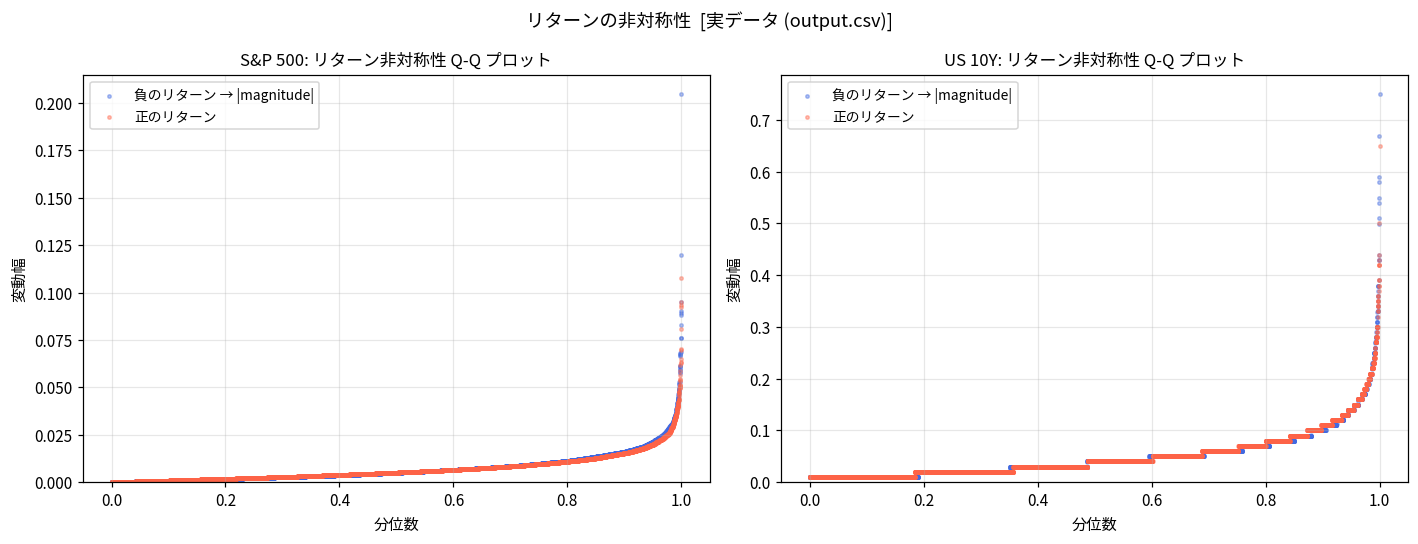

In [291]:
_datasets = [(df, "現在データ")]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)"))

# 縦軸スケールをデータセット間で統一（列ごとに全データセットの最大値で揃える）
_ylim_asym = {}
for col in ["sp500", "DGS10"]:
    all_vals = []
    for _data, _ in _datasets:
        r = _data[col].dropna()
        all_vals.extend(np.abs(r[r < 0].values))
        all_vals.extend(r[r > 0].values)
    all_vals = np.array(all_vals)
    _ylim_asym[col] = (0.0, float(np.max(all_vals)) * 1.05)

for _data, _dlabel in _datasets:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (col, label) in zip(axes, [("sp500","S&P 500"), ("DGS10","US 10Y")]):
        r = _data[col].dropna()
        neg_abs = np.sort(np.abs(r[r < 0].values))
        pos     = np.sort(r[r > 0].values)
        n = min(len(neg_abs), len(pos))
        q = np.linspace(0, 1, n)
        ax.scatter(q, np.quantile(neg_abs, q), s=5, alpha=0.4, c="royalblue",
                   label="負のリターン → |magnitude|")
        ax.scatter(q, np.quantile(pos, q),     s=5, alpha=0.4, c="tomato",
                   label="正のリターン")
        ax.set_ylim(_ylim_asym[col])
        ax.set_xlabel("分位数"); ax.set_ylabel("変動幅")
        ax.set_title(f"{label}: リターン非対称性 Q-Q プロット")
        ax.legend(fontsize=9)
    fig.suptitle(f"リターンの非対称性  [{_dlabel}]", fontsize=12)
    plt.tight_layout(); plt.show()


## 4. ボラティリティクラスタリング & リターン自己相関

| 系列 | 期待される特性 |
|------|--------------|
| リターン `r` | 自己相関なし（弱形式効率性） |
| 絶対リターン `abs(r)` | 有意な正の自己相関（ボラティリティ持続性） |
| 二乗リターン `r²` | 有意な正の自己相関（ボラティリティ持続性） |

ヒートマップで lag 1d / 3d / 5d / 7d の自己相関係数を確認する．


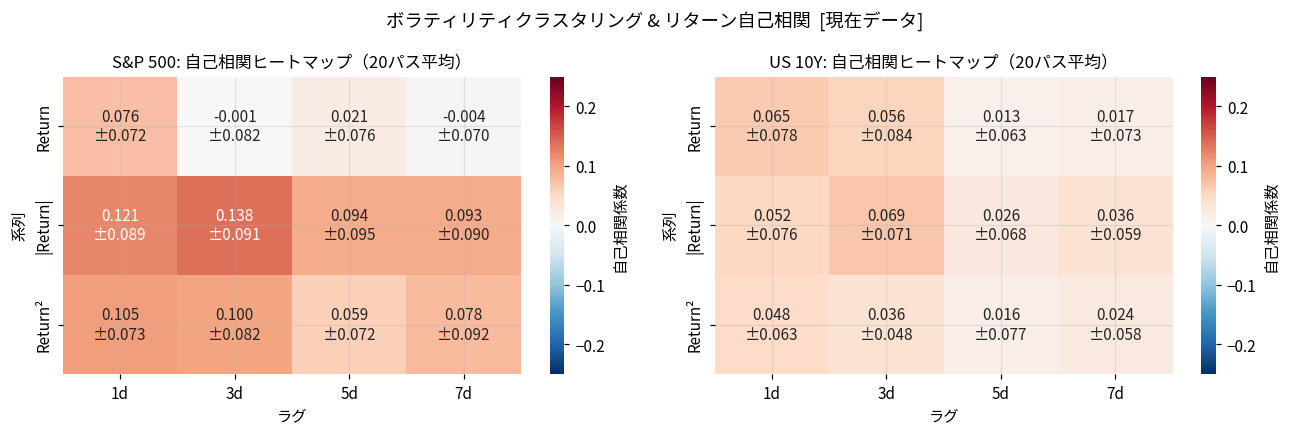

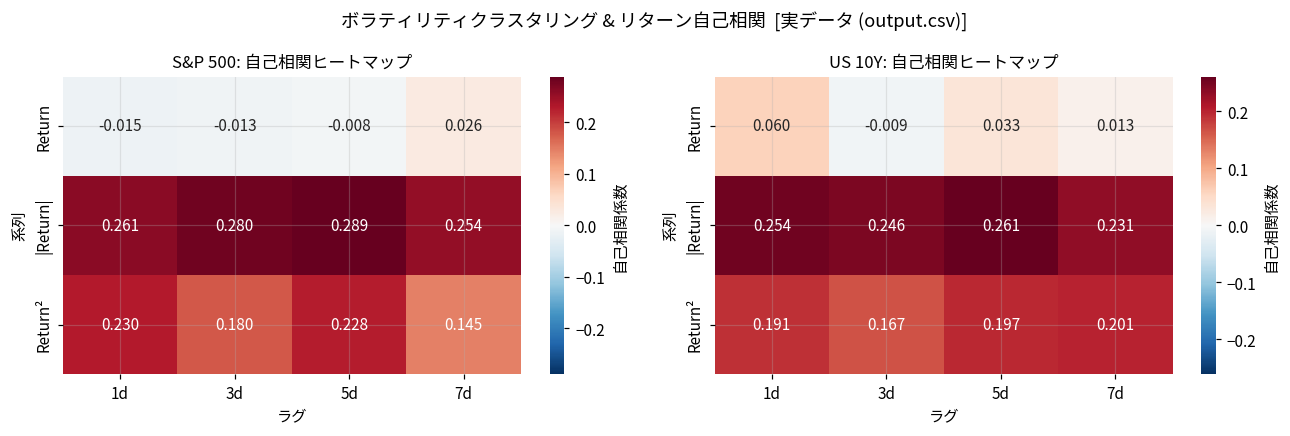

In [292]:
def compute_acf_table(r, lags=(1, 3, 5, 7)):
    r = r.dropna()
    rows = {}
    for lag in lags:
        rows[f"{lag}d"] = {
            "Return":   round(r.autocorr(lag=lag), 3),
            "|Return|": round(r.abs().autocorr(lag=lag), 3),
            "Return²":  round((r**2).autocorr(lag=lag), 3),
        }
    return pd.DataFrame(rows).T

def _acf_mean_std(paths, col, lags=(1, 3, 5, 7)):
    """全パスで ACF テーブルを計算して mean / std を返す。"""
    tbls = [compute_acf_table(p[col].dropna(), lags) for p in paths]
    arr  = np.stack([t.values for t in tbls])   # (n_paths, n_lags, 3)
    mean = pd.DataFrame(arr.mean(0), index=tbls[0].index, columns=tbls[0].columns)
    std  = pd.DataFrame(arr.std(0),  index=tbls[0].index, columns=tbls[0].columns)
    return mean, std

_datasets = [(df, "現在データ", _all_paths)]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)", [df_real_ref]))

for _data, _dlabel, _paths in _datasets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (col, label) in zip(axes, [("sp500","S&P 500"), ("DGS10","US 10Y")]):
        mean_tbl, std_tbl = _acf_mean_std(_paths, col)

        # 注釈: 複数パスなら "mean\n±std"、1パスなら値のみ
        if len(_paths) > 1:
            annot = np.array([[f"{m:.3f}\n±{s:.3f}"
                               for m, s in zip(mr, sr)]
                              for mr, sr in zip(mean_tbl.values, std_tbl.values)])
            annot_df = pd.DataFrame(annot, index=mean_tbl.index, columns=mean_tbl.columns).T
        else:
            annot_df = True

        vmax = max(0.25, mean_tbl.abs().max().max())
        sns.heatmap(mean_tbl.T, ax=ax, annot=annot_df, fmt="s" if len(_paths) > 1 else ".3f",
                    cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                    cbar_kws={"label": "自己相関係数"})
        suffix = f"（{len(_paths)}パス平均）" if len(_paths) > 1 else ""
        ax.set_title(f"{label}: 自己相関ヒートマップ{suffix}")
        ax.set_xlabel("ラグ"); ax.set_ylabel("系列")
    fig.suptitle(f"ボラティリティクラスタリング & リターン自己相関  [{_dlabel}]", fontsize=12)
    plt.tight_layout(); plt.show()

In [293]:
_datasets = [(df, "現在データ", _all_paths)]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)", [df_real_ref]))

for _data, _dlabel, _paths in _datasets:
    print(f"[{_dlabel}]  ({'各パス平均' if len(_paths)>1 else '1系列'})")
    print(f"  {'Asset':8} {'Series':6} {'LB-lag10 p値 mean':>18}  {'±std':>8}  判定")
    print("  " + "-" * 52)
    for col, label in [("sp500","sp500"), ("DGS10","DGS10")]:
        for name, transform in [("r", lambda r: r),
                                 ("|r|", lambda r: r.abs()),
                                 ("r²",  lambda r: r**2)]:
            pvals = []
            for p in _paths:
                r = p[col].dropna()
                lb = acorr_ljungbox(transform(r), lags=[10], return_df=True)
                pvals.append(lb["lb_pvalue"].values[0])
            mean_p, std_p = np.mean(pvals), np.std(pvals)
            judge = "*** 有意" if mean_p < 0.01 else ("* 有意" if mean_p < 0.05 else "非有意")
            print(f"  {label:8} {name:6}  {mean_p:>18.4e}  {std_p:>8.4e}  {judge}")
    print()

[現在データ]  (各パス平均)
  Asset    Series   LB-lag10 p値 mean      ±std  判定
  ----------------------------------------------------
  sp500    r               2.8048e-01  2.3131e-01  非有意
  sp500    |r|             9.1934e-02  2.0082e-01  非有意
  sp500    r²              9.0808e-02  1.8340e-01  非有意
  DGS10    r               3.1340e-01  2.7313e-01  非有意
  DGS10    |r|             2.8804e-01  3.1320e-01  非有意
  DGS10    r²              4.2310e-01  3.5302e-01  非有意

[実データ (output.csv)]  (1系列)
  Asset    Series   LB-lag10 p値 mean      ±std  判定
  ----------------------------------------------------
  sp500    r               6.8337e-05  0.0000e+00  *** 有意
  sp500    |r|             0.0000e+00  0.0000e+00  *** 有意
  sp500    r²              0.0000e+00  0.0000e+00  *** 有意
  DGS10    r               2.3229e-13  0.0000e+00  *** 有意
  DGS10    |r|             0.0000e+00  0.0000e+00  *** 有意
  DGS10    r²              0.0000e+00  0.0000e+00  *** 有意



## 5. レバレッジ効果

当期ボラティリティ十分位ごとに `corr(r_t, 将来平均ボラティリティ)` を集計．
高ボラ局面（十分位 8〜10）で値が負に大きくなるほどレバレッジ効果が強い．


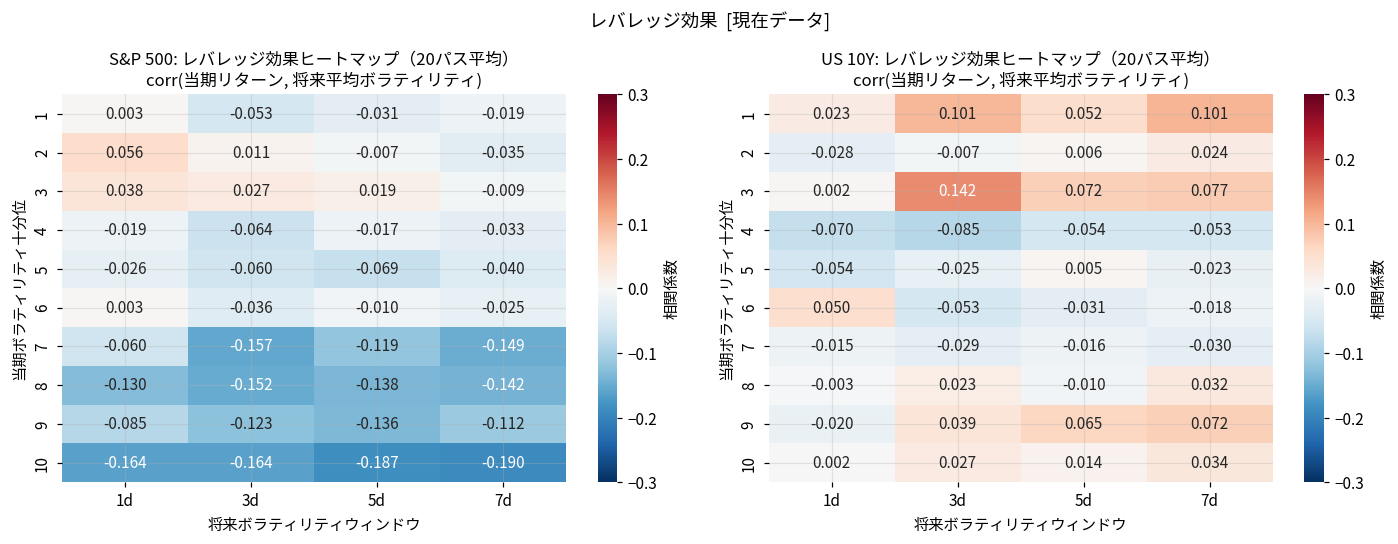

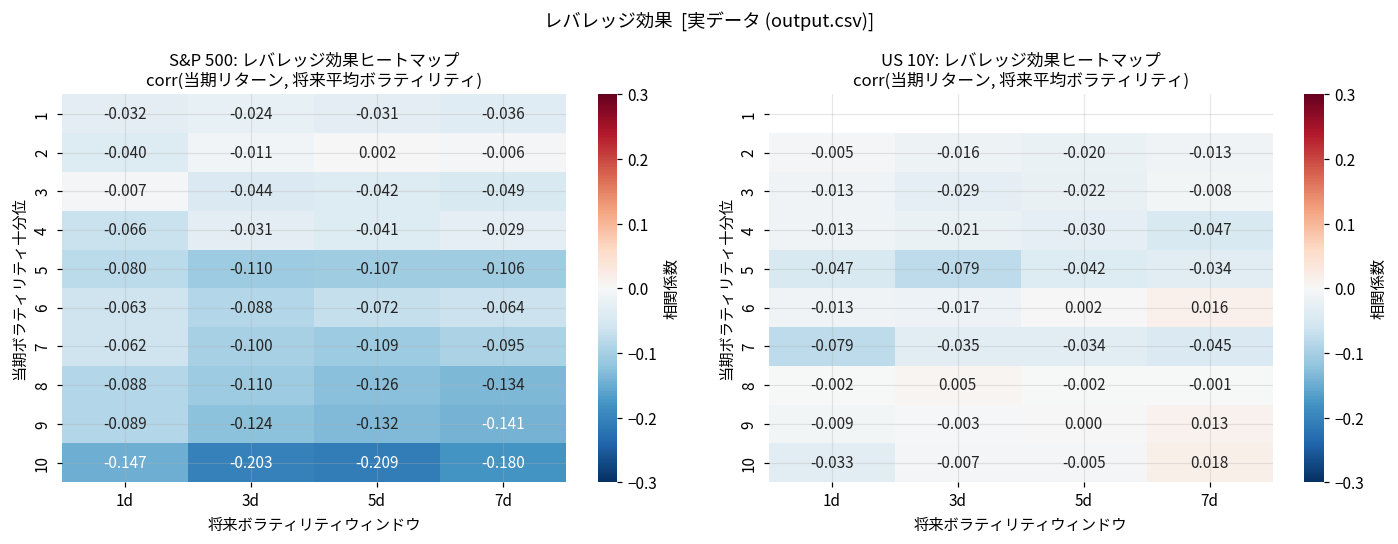

In [294]:
def compute_leverage_heatmap(r, windows=(1, 3, 5, 7), n_deciles=10):
    r = r.dropna().reset_index(drop=True)
    vol = r.abs()
    vol_decile = np.ceil(vol.rank(pct=True) * n_deciles).clip(1, n_deciles).astype(int)
    result = {}
    for w in windows:
        future_avg_vol = vol.rolling(w).mean().shift(-w)
        col = {}
        for d in range(1, n_deciles + 1):
            idx = vol_decile[vol_decile == d].index
            r_d  = r.iloc[idx].dropna()
            fv_d = future_avg_vol.iloc[idx].dropna()
            common = r_d.index.intersection(fv_d.index)
            col[d] = round(np.corrcoef(r_d[common], fv_d[common])[0, 1], 3) if len(common) > 5 else np.nan
        result[f"{w}d"] = col
    df_res = pd.DataFrame(result)
    df_res.index.name = "当期ボラティリティ十分位"
    return df_res

_datasets = [(df, "現在データ", _all_paths)]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)", [df_real_ref]))

for _data, _dlabel, _paths in _datasets:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (col, label) in zip(axes, [("sp500","S&P 500"), ("DGS10","US 10Y")]):
        # 全パスで計算して平均
        tbls = [compute_leverage_heatmap(p[col]) for p in _paths]
        arr  = np.stack([t.values for t in tbls])
        mean_tbl = pd.DataFrame(arr.mean(0), index=tbls[0].index, columns=tbls[0].columns)
        mean_tbl.index.name = tbls[0].index.name

        sns.heatmap(mean_tbl, ax=ax, annot=True, fmt=".3f",
                    cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3,
                    cbar_kws={"label": "相関係数"})
        suffix = f"（{len(_paths)}パス平均）" if len(_paths) > 1 else ""
        ax.set_title(f"{label}: レバレッジ効果ヒートマップ{suffix}\ncorr(当期リターン, 将来平均ボラティリティ)")
        ax.set_xlabel("将来ボラティリティウィンドウ")
        ax.set_ylabel("当期ボラティリティ十分位")
    fig.suptitle(f"レバレッジ効果  [{_dlabel}]", fontsize=12)
    plt.tight_layout(); plt.show()

## 6. 相関の時変性

90 日ローリングウィンドウで sp500 と DGS10 の相関を計算し時系列でプロット．
1990 年代後半を境に符号が反転（株債相関のレジーム転換）していることが確認できる．


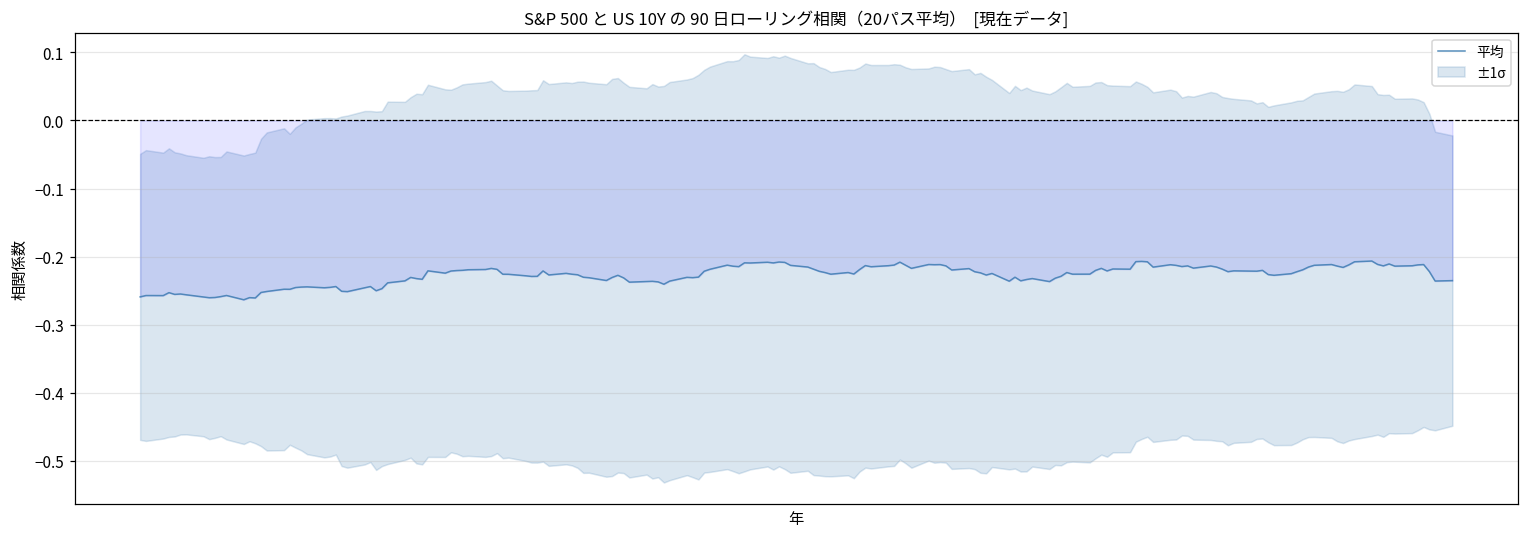

  [実データ (output.csv)] 1966-1999: 平均相関 = -0.307  (n=8012)
  [実データ (output.csv)] 2000-2019: 平均相関 = +0.326  (n=4709)
  [実データ (output.csv)] 2020-2026: 平均相関 = +0.057  (n=1486)


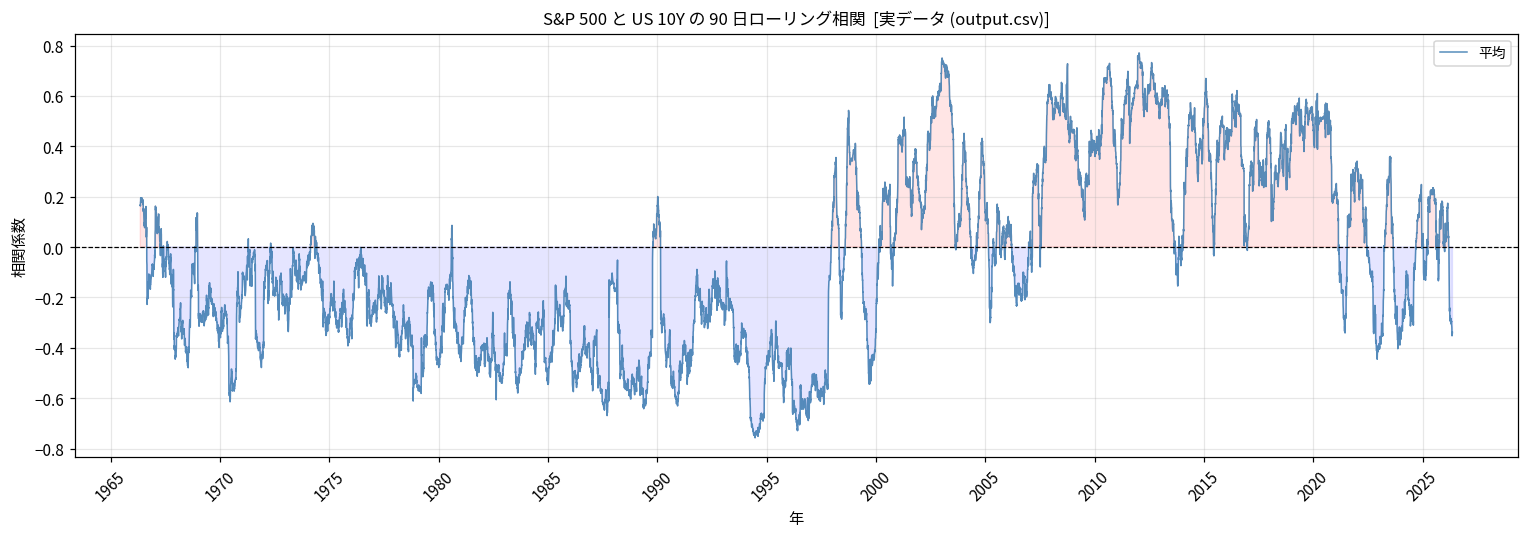

In [295]:
ROLLING_WINDOW = 90

_datasets = [(df, dates, "現在データ", _all_paths)]
if _show_real:
    _datasets.append((df_real_ref, df_real_ref["Date"], "実データ (output.csv)", [df_real_ref]))

for _data, _dates, _dlabel, _paths in _datasets:
    # 全パスのローリング相関を計算してスタック
    rc_all = pd.concat(
        [p["sp500"].rolling(ROLLING_WINDOW).corr(p["DGS10"]).rename(i)
         for i, p in enumerate(_paths)], axis=1
    )
    rc_mean = rc_all.mean(axis=1)
    rc_std  = rc_all.std(axis=1)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(_dates, rc_mean.values, color="steelblue", lw=1.0, alpha=0.9, label="平均")
    if len(_paths) > 1:
        ax.fill_between(_dates,
                        (rc_mean - rc_std).values,
                        (rc_mean + rc_std).values,
                        alpha=0.2, color="steelblue", label="±1σ")
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.fill_between(_dates, rc_mean.values, 0, where=rc_mean.values > 0,
                    alpha=0.10, color="red")
    ax.fill_between(_dates, rc_mean.values, 0, where=rc_mean.values < 0,
                    alpha=0.10, color="blue")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.xticks(rotation=45)
    suffix = f"（{len(_paths)}パス平均）" if len(_paths) > 1 else ""
    ax.set_xlabel("年"); ax.set_ylabel("相関係数")
    ax.set_title(f"S&P 500 と US 10Y の {ROLLING_WINDOW} 日ローリング相関{suffix}  [{_dlabel}]")
    ax.legend(fontsize=9)

    for label, (s, e) in [("1966-1999", ("1966","1999")),
                           ("2000-2019", ("2000","2019")),
                           ("2020-2026", ("2020","2026"))]:
        sub = rc_mean[(_dates >= s) & (_dates < e)].dropna()
        if len(sub) > 0:
            print(f"  [{_dlabel}] {label}: 平均相関 = {sub.mean():+.3f}  (n={len(sub)})")

    plt.tight_layout(); plt.show()

## 7. 相関の非対称性

sp500 リターンを極端な分位数区間に分け，その区間内での sp500-DGS10 相関の平均を集計．
急落局面（≤1%）と通常局面で相関の符号や大きさが異なるかを確認する．


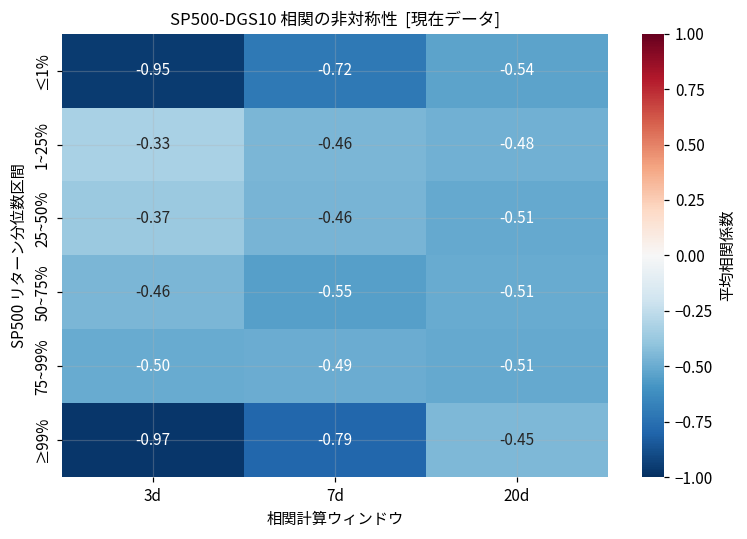

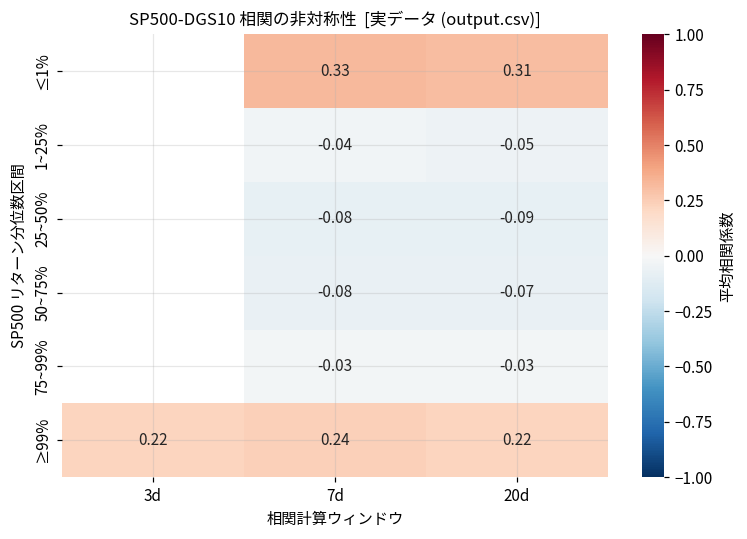

In [296]:
QUANTILE_BINS = {
    "≤1%":    (0.00, 0.01),
    "1~25%":  (0.01, 0.25),
    "25~50%": (0.25, 0.50),
    "50~75%": (0.50, 0.75),
    "75~99%": (0.75, 0.99),
    "≥99%":   (0.99, 1.00),
}
CORR_WINDOWS = [3, 7, 20]

_datasets = [(df, "現在データ")]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)"))

for _data, _dlabel in _datasets:
    sp_s = _data["sp500"].dropna()
    dg_s = _data["DGS10"].reindex(sp_s.index).dropna()
    common = sp_s.index.intersection(dg_s.index)
    sp_s, dg_s = sp_s[common], dg_s[common]

    result = {}
    for w in CORR_WINDOWS:
        corr_s = sp_s.rolling(w).corr(dg_s)
        col = {}
        for label, (lo_q, hi_q) in QUANTILE_BINS.items():
            lo_v = sp_s.quantile(lo_q); hi_v = sp_s.quantile(hi_q)
            mask = (sp_s >= lo_v) & (sp_s < hi_v) if hi_q < 1.0 else (sp_s >= lo_v)
            col[label] = round(corr_s[mask].mean(), 3)
        result[f"{w}d"] = col
    tbl = pd.DataFrame(result)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(tbl, ax=ax, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                cbar_kws={"label": "平均相関係数"})
    ax.set_title(f"SP500-DGS10 相関の非対称性  [{_dlabel}]")
    ax.set_xlabel("相関計算ウィンドウ"); ax.set_ylabel("SP500 リターン分位数区間")
    plt.tight_layout(); plt.show()


## 8. ボラティリティと相関の連動性

sp500 の日次絶対リターンを 20 分位に分け，各分位での sp500-DGS10 平均相関を集計．
上位分位（高ボラ局面）ほど相関の絶対値が大きければ連動性あり．


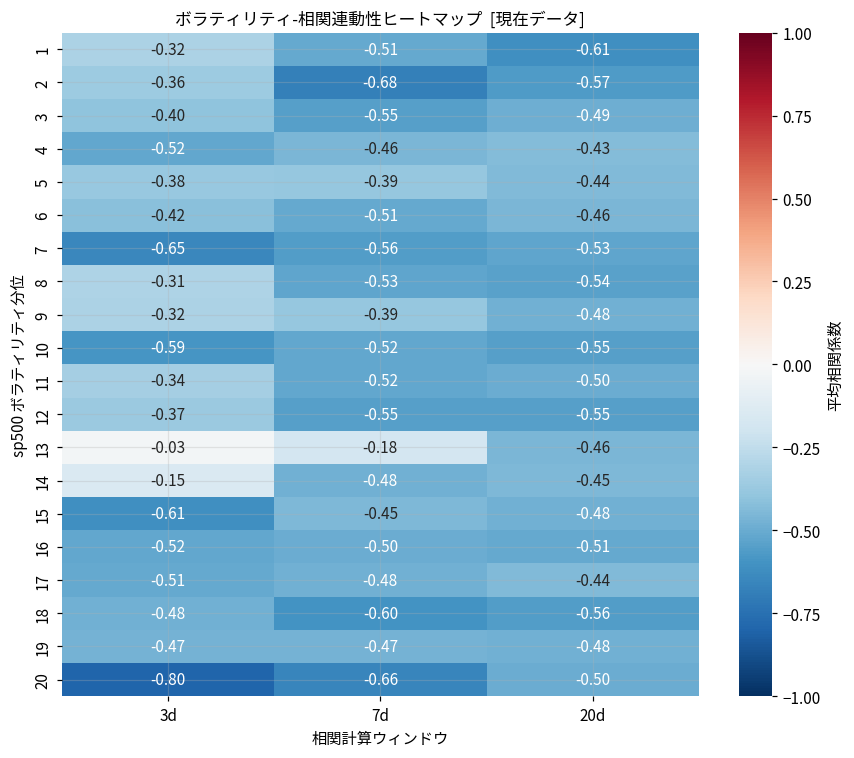

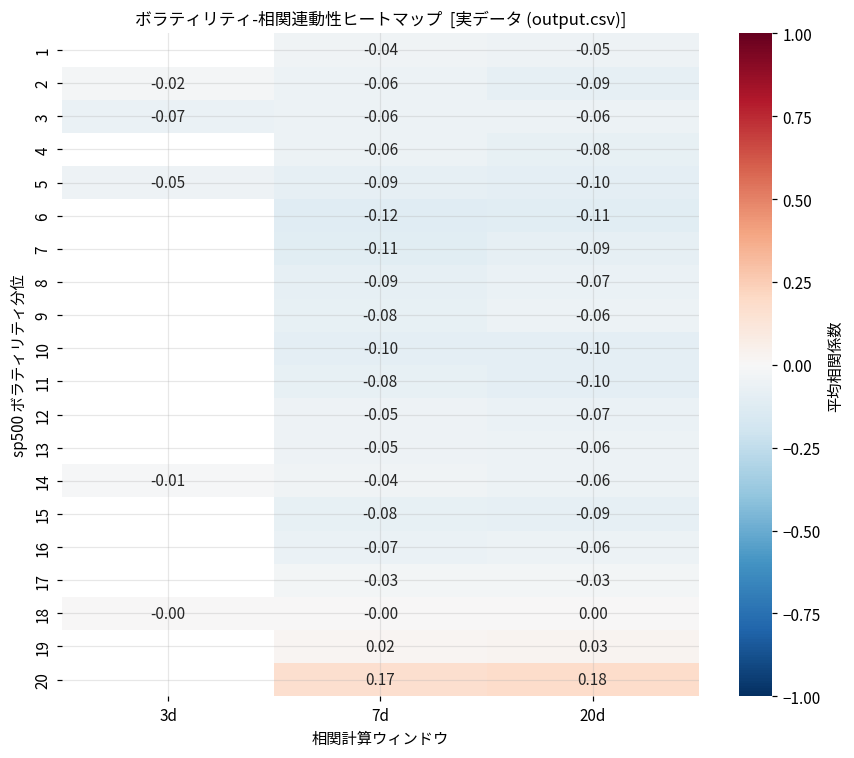

In [297]:
VOL_DECILES  = 20
CORR_WINDOWS = [3, 7, 20]

_datasets = [(df, "現在データ")]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)"))

for _data, _dlabel in _datasets:
    sp_s = _data["sp500"].dropna()
    dg_s = _data["DGS10"].reindex(sp_s.index).dropna()
    common = sp_s.index.intersection(dg_s.index)
    sp_s, dg_s = sp_s[common], dg_s[common]
    vol   = sp_s.abs()
    vol_q = np.ceil(vol.rank(pct=True) * VOL_DECILES).clip(1, VOL_DECILES).astype(int)

    result = {}
    for w in CORR_WINDOWS:
        corr_s = sp_s.rolling(w).corr(dg_s)
        result[f"{w}d"] = {d: round(corr_s[vol_q[vol_q == d].index].mean(), 2)
                           for d in range(1, VOL_DECILES + 1)}
    tbl = pd.DataFrame(result)

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(tbl, ax=ax, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                cbar_kws={"label": "平均相関係数"})
    ax.set_title(f"ボラティリティ-相関連動性ヒートマップ  [{_dlabel}]")
    ax.set_xlabel("相関計算ウィンドウ"); ax.set_ylabel("sp500 ボラティリティ分位")
    plt.tight_layout(); plt.show()


## 9. リード・ラグ現象

20 日移動平均を施したリターン同士の相互相関をラグ −90〜+90 日で計算．
正のラグで相関が強い → sp500 が DGS10 に先行．


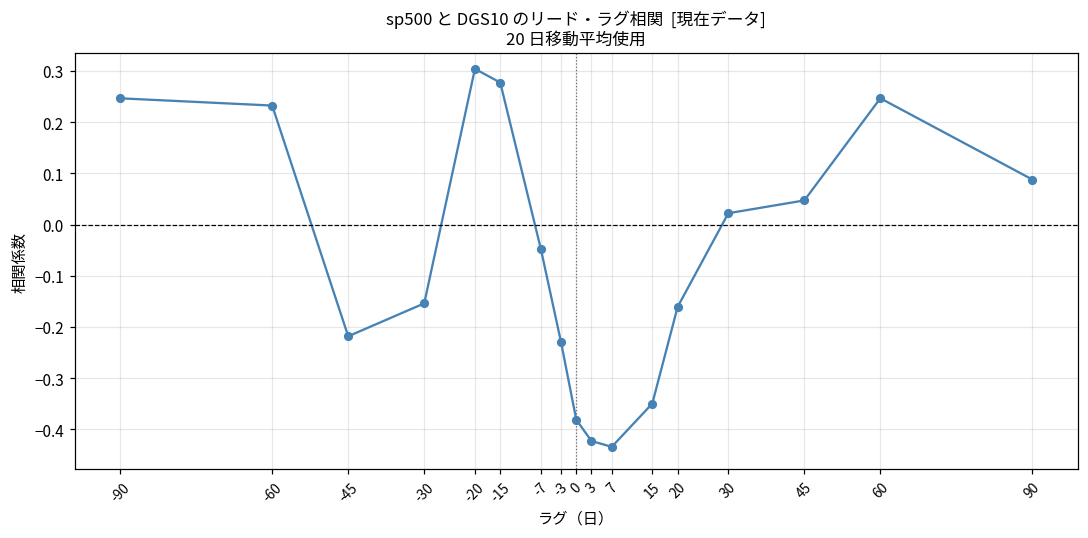

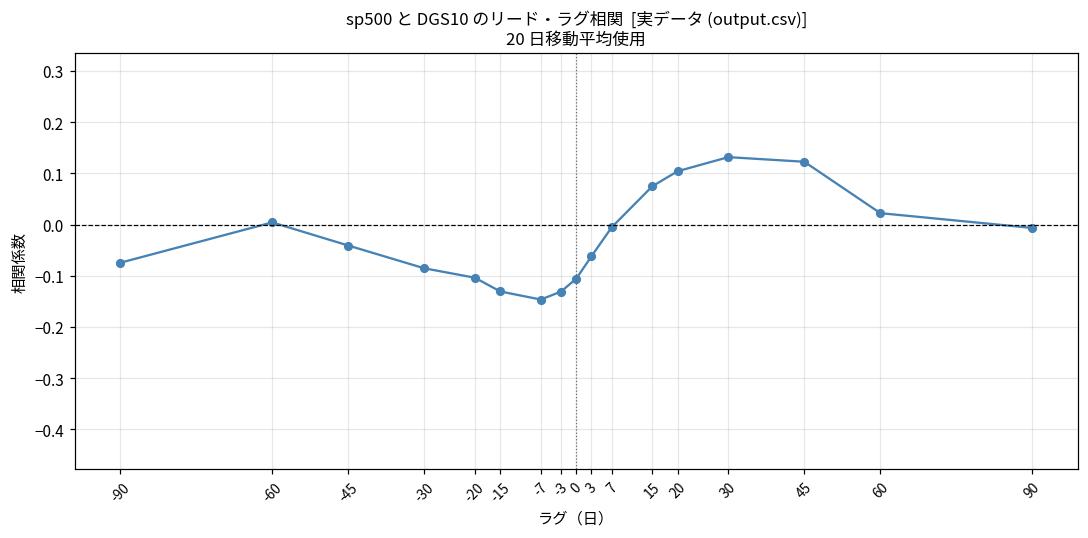

In [298]:
MA_WINDOW = 20
LAG_DAYS  = [-90, -60, -45, -30, -20, -15, -7, -3, 0, 3, 7, 15, 20, 30, 45, 60, 90]

_datasets = [(df, "現在データ")]
if _show_real:
    _datasets.append((df_real_ref, "実データ (output.csv)"))

def _lead_lag(data):
    sp_s = data["sp500"].dropna()
    dg_s = data["DGS10"].reindex(sp_s.index).dropna()
    sp_ma = sp_s.rolling(MA_WINDOW).mean().dropna()
    dg_ma = dg_s.rolling(MA_WINDOW).mean().dropna()
    common = sp_ma.index.intersection(dg_ma.index)
    sp_ma, dg_ma = sp_ma[common].values, dg_ma[common].values
    corrs = {}
    for lag in LAG_DAYS:
        if   lag > 0: corrs[lag] = np.corrcoef(sp_ma[:-lag], dg_ma[lag:])[0, 1]
        elif lag < 0: corrs[lag] = np.corrcoef(sp_ma[-lag:], dg_ma[:lag])[0, 1]
        else:         corrs[lag] = np.corrcoef(sp_ma, dg_ma)[0, 1]
    return pd.Series(corrs)

# ── 全データセットの相関値を先に計算して y 軸スケールを統一
_ll_all = {_dlabel: _lead_lag(_data) for _data, _dlabel in _datasets}
_all_vals = pd.concat(list(_ll_all.values()))
_ymin = float(_all_vals.min()) * 1.1 if _all_vals.min() < 0 else float(_all_vals.min()) * 0.9
_ymax = float(_all_vals.max()) * 1.1 if _all_vals.max() > 0 else float(_all_vals.max()) * 0.9
_ylim = (min(_ymin, -0.05), max(_ymax, 0.05))   # 最低でも 0 を含む範囲を確保

for _data, _dlabel in _datasets:
    ll = _ll_all[_dlabel]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ll.index, ll.values, "o-", color="steelblue", ms=5)
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.axvline(0, color="dimgray", ls=":", lw=0.8)
    ax.set_xticks(LAG_DAYS); ax.set_xticklabels(LAG_DAYS, rotation=45, fontsize=9)
    ax.set_ylim(_ylim)
    ax.set_xlabel("ラグ（日）"); ax.set_ylabel("相関係数")
    ax.set_title(f"sp500 と DGS10 のリード・ラグ相関  [{_dlabel}]\n{MA_WINDOW} 日移動平均使用")
    plt.tight_layout(); plt.show()


## 10. Diffusion Model 生成結果の検証（2023-2025 期間）

**比較設定**

| | 実データ | 生成データ |
|--|--|--|
| ファイル | `output.csv` | `diffusion/generated_paths_2023_2025.csv` |
| 開始条件 | 2023-01-03 の実水準 | `--sp500 3824.14  --dgs10 3.79` |
| 期間 | 2023-01-03 〜 2025-12-31（742 日） | 同日数（step 0 を除く） |
| 比較方法 | `PATH_ID` で1パスを選択して並べて表示 |  |


In [299]:
# ============================================================
# 比較するパスを選択（0 〜 n_paths-1 の整数）
PATH_ID = 0
# ============================================================

# ── 生成データ読み込み
gen_raw = pd.read_csv("diffusion/generated_paths_2023_2025.csv", parse_dates=["Date"])
gen_raw = gen_raw.sort_values(["path_id", "Date"]).reset_index(drop=True)

# step 0 は「2023年初の水準 / 2026年末の水準 − 1」という人工的なリターンなので除去
gen_all = gen_raw[gen_raw.groupby("path_id").cumcount() > 0].copy().reset_index(drop=True)

# ── 実データ 2023-2025（セクション1の [A]/[B]/[C] 切り替えに依存しないよう直接読む）
_df_real = pd.read_csv("output.csv", parse_dates=["Date"])
ref_real = (_df_real[(_df_real["Date"] >= "2023-01-03") & (_df_real["Date"] <= "2025-12-31")]
            .reset_index(drop=True))

# ── 選択パスを取り出し、日付を実データに揃える
gen_path = (gen_all[gen_all["path_id"] == PATH_ID]
            .reset_index(drop=True)
            .assign(Date=ref_real["Date"].values))

print(f"PATH_ID        : {PATH_ID}")
print(f"利用可能パス数 : {gen_all['path_id'].nunique()}  (0 〜 {gen_all['path_id'].max()})")
print(f"実データ日数   : {len(ref_real)}  ({ref_real['Date'].min().date()} 〜 {ref_real['Date'].max().date()})")
print(f"生成パス日数   : {len(gen_path)}")


PATH_ID        : 0
利用可能パス数 : 50  (0 〜 49)
実データ日数   : 742  (2023-01-03 〜 2025-12-31)
生成パス日数   : 742


In [300]:
# 実データ vs 生成パスの基本統計量を並べて確認
stats_tbl = pd.concat([
    ref_real[["sp500","DGS10"]].describe().round(4).add_suffix("_real"),
    gen_path[["sp500","DGS10"]].describe().round(4).add_suffix("_gen"),
], axis=1)
print(stats_tbl.to_string())


       sp500_real  DGS10_real  sp500_gen  DGS10_gen
count    742.0000    742.0000   742.0000   742.0000
mean       0.0008      0.0006    -0.0013    -0.0055
std        0.0095      0.0613     0.0105     0.0679
min       -0.0597     -0.2300    -0.0367    -0.2487
25%       -0.0036     -0.0400    -0.0083    -0.0474
50%        0.0010      0.0000    -0.0014    -0.0073
75%        0.0058      0.0400     0.0054     0.0389
max        0.0952      0.1900     0.0328     0.2139


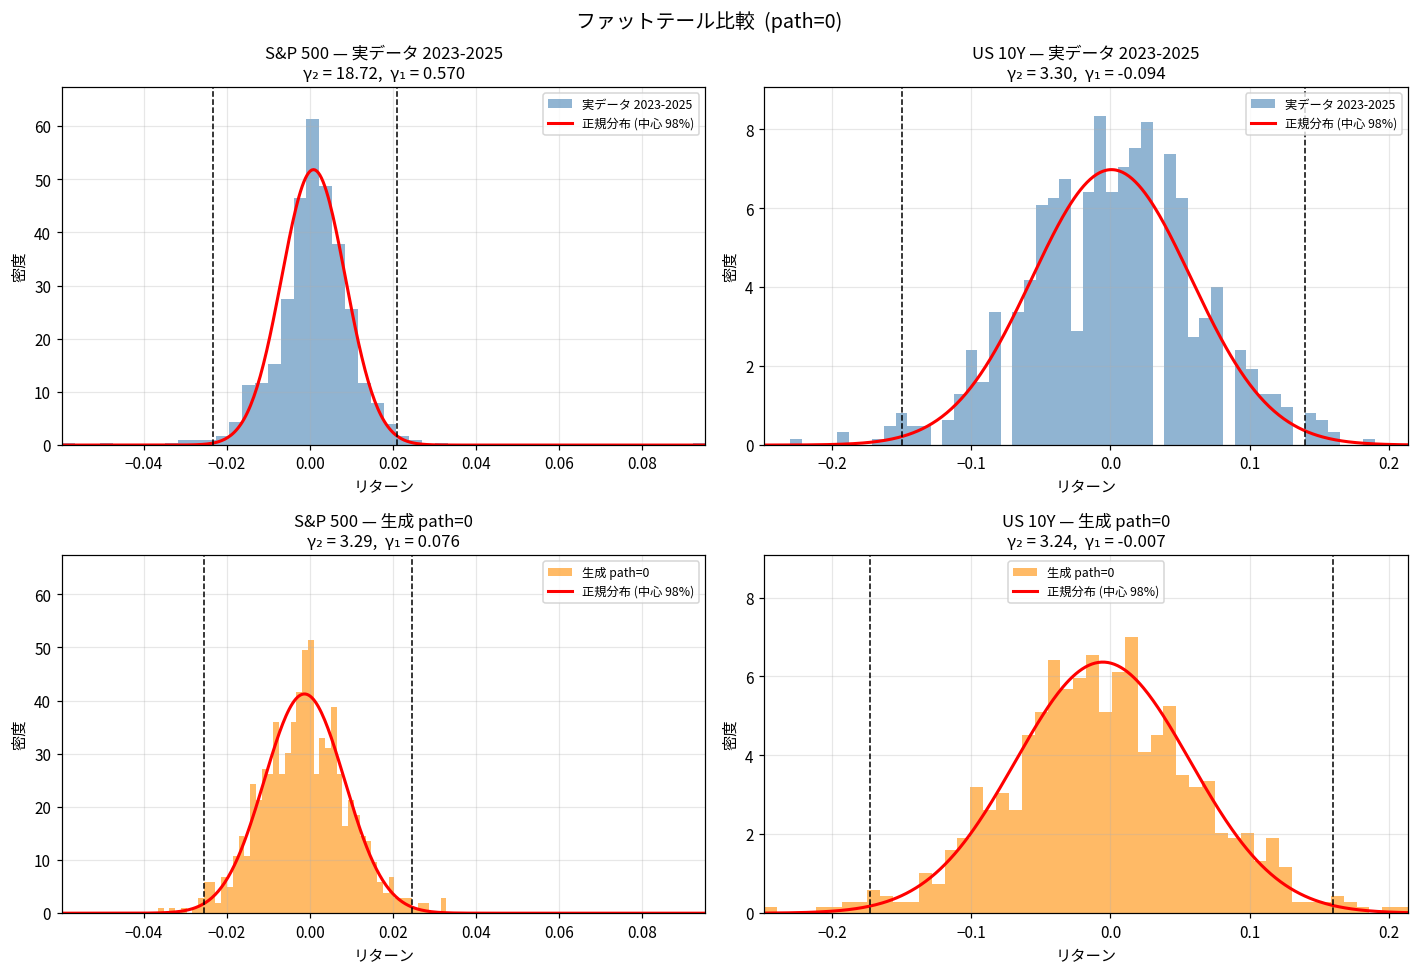

In [301]:
# ---------- ヒストグラム比較（統一スケール） ----------

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col_idx, col in enumerate(["sp500", "DGS10"]):
    # ── 両データを結合してスケールを事前計算
    all_r = pd.concat([ref_real[col].dropna(), gen_path[col].dropna()])
    xlim = (float(all_r.min()), float(all_r.max()))

    max_dens = 0.0
    for r_arr in [ref_real[col].dropna(), gen_path[col].dropna()]:
        lo, hi = np.percentile(r_arr, 1), np.percentile(r_arr, 99)
        r_c = r_arr[(r_arr >= lo) & (r_arr <= hi)]
        sig = r_c.std()
        if sig > 0:
            max_dens = max(max_dens, 1.0 / (sig * np.sqrt(2 * np.pi)))
    ylim = (0, max_dens * 1.3)

    for row_idx, (r_arr, src_label, color) in enumerate([
        (ref_real[col].dropna(), f"実データ 2023-2025", "steelblue"),
        (gen_path[col].dropna(), f"生成 path={PATH_ID}",  "darkorange"),
    ]):
        ax = axes[row_idx, col_idx]
        lo, hi = np.percentile(r_arr, 1), np.percentile(r_arr, 99)
        r_c = r_arr[(r_arr >= lo) & (r_arr <= hi)]
        mu, sigma = r_c.mean(), r_c.std()
        kurt = stats.kurtosis(r_arr, fisher=True) + 3

        ax.hist(r_arr, bins=50, density=True, alpha=0.6, color=color, label=src_label)
        x = np.linspace(xlim[0], xlim[1], 400)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label="正規分布 (中心 98%)")
        ax.axvline(lo, color="k", ls="--", lw=1)
        ax.axvline(hi, color="k", ls="--", lw=1)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        label_str = "S&P 500" if col == "sp500" else "US 10Y"
        ax.set_title(f"{label_str} — {src_label}\nγ₂ = {kurt:.2f},  γ₁ = {r_arr.skew():.3f}")
        ax.set_xlabel("リターン"); ax.set_ylabel("密度")
        ax.legend(fontsize=8)

fig.suptitle(f"ファットテール比較  (path={PATH_ID})", fontsize=13)
plt.tight_layout(); plt.show()


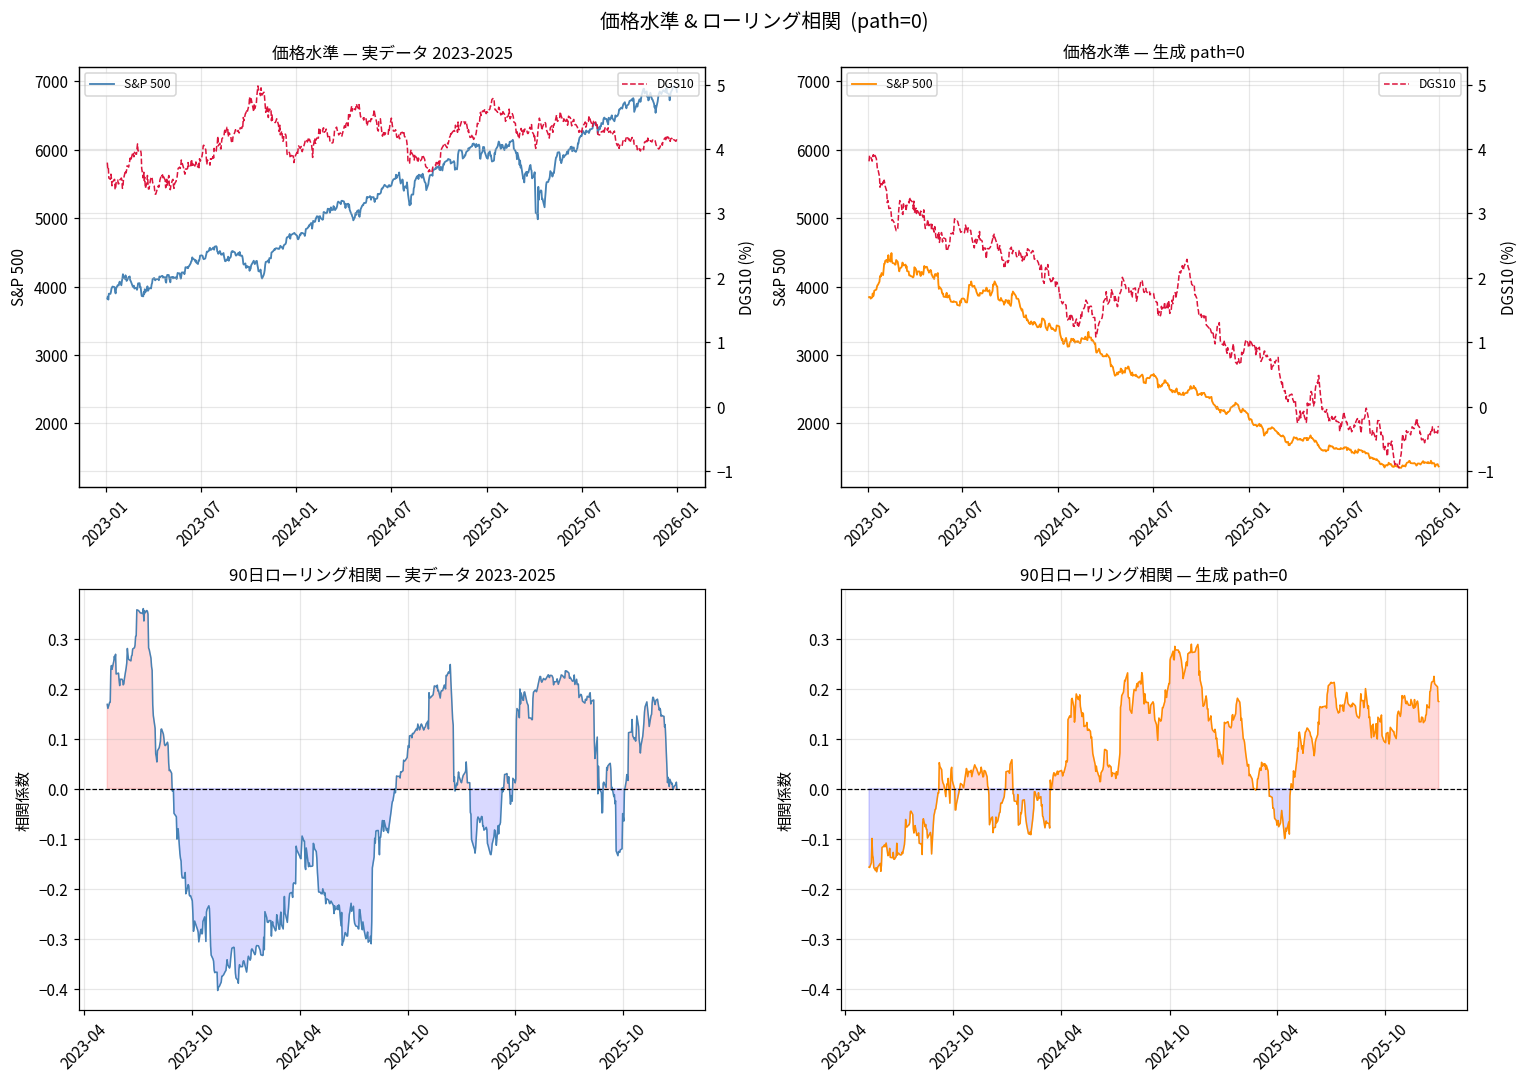

In [302]:
# ---------- 価格水準・ローリング相関の並列比較（統一スケール） ----------

# ── スケールを事前計算
_srcs = [ref_real, gen_path]

# 価格水準 y 軸
_sp_all  = pd.concat([s["sp500_abs"].dropna() for s in _srcs])
_dg_all  = pd.concat([s["DGS10_abs"].dropna() for s in _srcs])
_sp_pad  = (_sp_all.max() - _sp_all.min()) * 0.05
_dg_pad  = (_dg_all.max() - _dg_all.min()) * 0.05
_sp_ylim = (float(_sp_all.min()) - _sp_pad, float(_sp_all.max()) + _sp_pad)
_dg_ylim = (float(_dg_all.min()) - _dg_pad, float(_dg_all.max()) + _dg_pad)

# ローリング相関 y 軸
_rc_all  = pd.concat([src["sp500"].rolling(ROLLING_WINDOW).corr(src["DGS10"])
                      for src in _srcs]).dropna()
_rc_pad  = (_rc_all.max() - _rc_all.min()) * 0.05
_rc_ylim = (float(_rc_all.min()) - _rc_pad, float(_rc_all.max()) + _rc_pad)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 上段: 価格水準
for ax, (src, label, color) in zip(axes[0], [
    (ref_real, f"実データ 2023-2025",   "steelblue"),
    (gen_path, f"生成 path={PATH_ID}", "darkorange"),
]):
    ax2 = ax.twinx()
    ax.plot(src["Date"], src["sp500_abs"], color=color,     lw=1.2, label="S&P 500")
    ax2.plot(src["Date"], src["DGS10_abs"], color="crimson", lw=1.0, ls="--", label="DGS10")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_ylim(_sp_ylim); ax2.set_ylim(_dg_ylim)
    ax.set_title(f"価格水準 — {label}")
    ax.set_ylabel("S&P 500"); ax2.set_ylabel("DGS10 (%)")
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

# ── 下段: ローリング相関
for ax, (src, label, color) in zip(axes[1], [
    (ref_real, f"実データ 2023-2025",   "steelblue"),
    (gen_path, f"生成 path={PATH_ID}", "darkorange"),
]):
    rc = src["sp500"].rolling(ROLLING_WINDOW).corr(src["DGS10"])
    ax.plot(src["Date"], rc, color=color, lw=1.0)
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.fill_between(src["Date"], rc, 0, where=rc > 0, alpha=0.15, color="red")
    ax.fill_between(src["Date"], rc, 0, where=rc < 0, alpha=0.15, color="blue")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_ylim(_rc_ylim)
    ax.set_title(f"{ROLLING_WINDOW}日ローリング相関 — {label}")
    ax.set_ylabel("相関係数")

fig.suptitle(f"価格水準 & ローリング相関  (path={PATH_ID})", fontsize=13)
plt.tight_layout(); plt.show()


In [303]:
def show_scorecard(r_real, d_real, r_gen, d_gen, path_id, asset_label=""):
    rows = []
    for name, real_val, gen_val in [
        ("Fat tail  尖度 γ₂",
         stats.kurtosis(r_real, fisher=True) + 3,
         stats.kurtosis(r_gen,  fisher=True) + 3),
        ("Neg skew  歪度 γ₁",
         float(r_real.skew()),
         float(r_gen.skew())),
        ("|r| ACF lag1",
         r_real.abs().autocorr(lag=1),
         r_gen.abs().autocorr(lag=1)),
        ("r   ACF lag1",
         r_real.autocorr(lag=1),
         r_gen.autocorr(lag=1)),
        ("Leverage lag1-5 mean",
         np.mean([np.corrcoef(r_real.values[:-l], r_real.abs().values[l:])[0,1] for l in range(1,6)]),
         np.mean([np.corrcoef(r_gen.values[:-l],  r_gen.abs().values[l:])[0,1]  for l in range(1,6)])),
        ("Roll-corr std (90d)",
         r_real.rolling(90).corr(d_real).dropna().std(),
         r_gen.rolling(90).corr(d_gen).dropna().std()),
    ]:
        rows.append({"指標": name, "実データ": round(real_val, 4), f"生成 (path={path_id})": round(gen_val, 4)})

    tbl = pd.DataFrame(rows).set_index("指標")
    header = f"  [{asset_label}  '実データ 2023-2025'  vs  '生成 path={path_id}']"
    print(header)
    print("  " + "─" * (len(header) - 2))
    print(tbl.to_string())

    lags = [1, 3, 5, 7]
    print(f"\n  ACF 詳細:")
    print(f"  {'':>8}  " + "  ".join(f"lag{l}d" for l in lags))
    for sl, sr, sg in [("r",  r_real,       r_gen),
                        ("|r|", r_real.abs(), r_gen.abs()),
                        ("r²",  r_real**2,    r_gen**2)]:
        rr = "  ".join(f"{sr.autocorr(lag=l):+.3f}" for l in lags)
        rg = "  ".join(f"{sg.autocorr(lag=l):+.3f}" for l in lags)
        print(f"  {sl:>8} 実: {rr}")
        print(f"  {'':>8} 生: {rg}")
    print()


r_real = ref_real["sp500"].dropna().reset_index(drop=True)
d_real = ref_real["DGS10"].dropna().reset_index(drop=True)
r_gen  = gen_path["sp500"].dropna().reset_index(drop=True)
d_gen  = gen_path["DGS10"].dropna().reset_index(drop=True)

show_scorecard(r_real, d_real, r_gen, d_gen, PATH_ID, asset_label="S&P 500")

  [S&P 500  '実データ 2023-2025'  vs  '生成 path=0']
  ────────────────────────────────────────────
                         実データ  生成 (path=0)
指標                                        
Fat tail  尖度 γ₂       18.7210       3.2902
Neg skew  歪度 γ₁        0.5699       0.0760
|r| ACF lag1           0.1821       0.0290
r   ACF lag1          -0.0406       0.0671
Leverage lag1-5 mean  -0.1336      -0.0059
Roll-corr std (90d)    0.2027       0.1101

  ACF 詳細:
            lag1d  lag3d  lag5d  lag7d
         r 実: -0.041  -0.101  -0.022  -0.013
           生: +0.067  +0.050  -0.032  +0.045
       |r| 実: +0.182  +0.220  +0.163  +0.095
           生: +0.029  +0.015  +0.036  -0.031
        r² 実: +0.181  +0.298  +0.077  +0.043
           生: +0.033  +0.005  +0.021  -0.027



In [304]:
show_scorecard(d_real, r_real, d_gen, r_gen, PATH_ID, asset_label="US 10Y (DGS10)")

  [US 10Y (DGS10)  '実データ 2023-2025'  vs  '生成 path=0']
  ───────────────────────────────────────────────────
                        実データ  生成 (path=0)
指標                                       
Fat tail  尖度 γ₂       3.3015       3.2387
Neg skew  歪度 γ₁      -0.0936      -0.0069
|r| ACF lag1          0.0963       0.0195
r   ACF lag1         -0.0089       0.0958
Leverage lag1-5 mean -0.0355       0.0052
Roll-corr std (90d)   0.2027       0.1101

  ACF 詳細:
            lag1d  lag3d  lag5d  lag7d
         r 実: -0.009  +0.014  +0.011  +0.023
           生: +0.096  -0.032  -0.019  -0.058
       |r| 実: +0.096  +0.113  +0.063  +0.083
           生: +0.019  +0.020  -0.013  +0.025
        r² 実: +0.112  +0.115  +0.099  +0.087
           生: +0.010  +0.009  -0.037  +0.079

